# TRABAJO FINAL CIENCIA DE DATOS 3
### ALUMNA SABRINA BENEDETTO
### COMISION 90480

# INTRODUCCION

#### Problema de negocio  
Los mercados financieros son sensibles a la información disponible (las noticias y el sentimiento del mercado influyen en las decisiones de los inversores y, por ende, en el comportamiento de los índices bursátiles). Por tanto, identificar patrones en el texto de las noticias financieras que anticipen movimientos del mercado es un problema de alto valor para la industria financiera.

En este proyecto se analiza si el contenido de los titulares de noticias financieras permite predecir si el índice S&P 500 va a subir o bajar ese día, combinando técnicas de Procesamiento de Lenguaje Natural (NLP) con modelos de clasificación supervisada.

#### Origen de los datos
Se trabajará con una base de datos de [Kaggle](https://www.kaggle.com) que contiene titulares de noticias financieras y la evolución del **Índice S&P 500** (el cual se basa en la capitalización bursátil de 500 grandes empresas que poseen acciones que cotizan en las bolsas NYSE o NASDAQ, y captura aproximadamente el 80 % de toda la capitalización de mercado en Estados Unidos).   

#### Objetivo  
Vincular el sentimiento de las noticias con el movimiento del mercado (variación del precio de cierre del índice).

#### Hipótesis  
El análisis de sentimiento de noticias financieras puede ser una señal para anticipar el comportamiento del índice S&P 500.

#### Definición de las variables  
| Variable | Tipo | Descripción |
|----------|------|-------------|
| `Title` | Texto | Titular de la noticia financiera. Variable de entrada para el análisis NLP y los modelos |
| `Date` | Fecha | Fecha de publicación del titular. Se usa para ordenar los datos y calcular la variación diaria del índice |
| `CP` | Numérico | Precio de cierre del S&P 500 ese día (Closing Price) |
| `mercado` | Binaria (0/1) | Variable objetivo construida a partir de `CP`. Indica si el índice subió (1) o bajó (0) respecto al día anterior |

#### Librerías  
| Librería | Uso |
|----------|-----|
| `pandas` | Manipulación y análisis de datos |
| `numpy` | Operaciones numéricas |
| `matplotlib` | Visualización de datos |
| `re` | Limpieza de texto con expresiones regulares |
| `spaCy` | Tokenización, lematización y eliminación de stopwords |
| `wordcloud` | Generación de nubes de palabras |
| `nltk` / `VADER` | Análisis de sentimiento |
| `sklearn` | Vectorización (TF-IDF) y modelo de Regresión Logística |
| `tensorflow` / `keras` | Construcción y entrenamiento de la red neuronal MLP |
| `transformers` / `torch` | Implementación de FinBERT |

#### Desarrollo del trabajo
Siguiendo las consignas , el trabajo práctico se plantea en **2 etapas**:  

**Etapa 1 (NLP)**: limpiar y procesar los titulares de noticias, nube de palabras, análisis de N-gramas y análisis de sentimiento con VADER.
**Etapa 2 (vectorización y modelo)**: con el objetivo de predecir si el S&P 500 subió o bajó ese día respecto del anterior (variable objetivo binaria → sube=1, baja=0); se vectoriza con TF-IDF y se entrenan los siguientes modelos:
- modelo de **Machine Learning**: Regresión Logística
- modelo de **Deep Learning**: Red Neuronal MLP (con y sin ajustes) y FinBERT (modelo Transformer preentrenado en textos financieros).

# PRESENTACIÓN DE LA BASE DE DATOS

In [1]:
# Conexión a la base de datos de kaggle
# Importo la librería os que permite interactuar con el sistema operativo
import os

# Configuro mis credenciales de Kaggle como variables de entorno
# las variables de entorno son una forma segura de pasar credenciales sin escribirlas directamente en el código
os.environ['KAGGLE_USERNAME'] = 'sabrinabenedetto '
os.environ['KAGGLE_KEY'] = 'KGAT_01c4003773f5cebe0e33fc4ac2becf33'

# Importo la API de Kaggle para poder descargar datasets directamente desde el notebook
import kaggle

# Descargo el dataset indicando:
#    - el nombre del dataset en Kaggle
#    - path='.': que se guarde en la carpeta actual
#    - unzip=True: que descomprima el zip automáticamente
kaggle.api.dataset_download_files(
    'dyutidasmahaptra/s-and-p-500-with-financial-news-headlines-20082024',
    path='.',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/dyutidasmahaptra/s-and-p-500-with-financial-news-headlines-20082024


In [2]:

# Listo los archivos de la carpeta actual
import os

# Listo todos los archivos y carpetas en el directorio de trabajo actual para verificar que se descragó ok
archivos = os.listdir('.')

# Recorro la lista e imprimo cada nombre
for archivo in archivos:
    print(archivo)

.config
sp500_headlines_2008_2024.csv
sample_data


In [3]:
import pandas as pd

# Cargo el dataset en un DataFrame
# El archivo contiene los titulares de noticias financieras junto con datos del S&P 500
df = pd.read_csv('sp500_headlines_2008_2024.csv')

# Muestro las primeras filas para entender la estructura del dataset
df.head()

,Title,Date,CP
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16
2,2008 predictions for the S&P 500,2008-01-02,1447.16
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18


In [4]:
print(df.columns)
print(df.shape)

Index(['Title', 'Date', 'CP'], dtype='object')
(19127, 3)


#### Características del dataset
 El dataset tiene 19127 filas y  3 columnas:   
`Title` → a esta columna se le aplicará NLP  
`CP` → precio de cierre (closing price). A partir de este precio se construye la variable objetivo (si el precio subió o bajó respecto al día anterior → columna nueva 0/1)  
`Date` → para ordenar los datos cronológicamente y calcular la variación del precio  

In [5]:
# Determino cuántos titulares hay por día
print(df.groupby('Date')['Title'].count())

# Determino cuántos titulares hay por día en promedio
print("\n**Estdística descriptiva**")
print(df.groupby('Date')['Title'].count().describe())

Date
2008-01-02     3
2008-01-03     1
2008-01-07     1
2008-01-09     2
2008-01-10     1
              ..
2024-02-27    21
2024-02-28    19
2024-02-29    22
2024-03-01    31
2024-03-04    31
Name: Title, Length: 3507, dtype: int64

**Estdística descriptiva**
count    3507.000000
mean        5.453949
std         5.573481
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        55.000000
Name: Title, dtype: float64


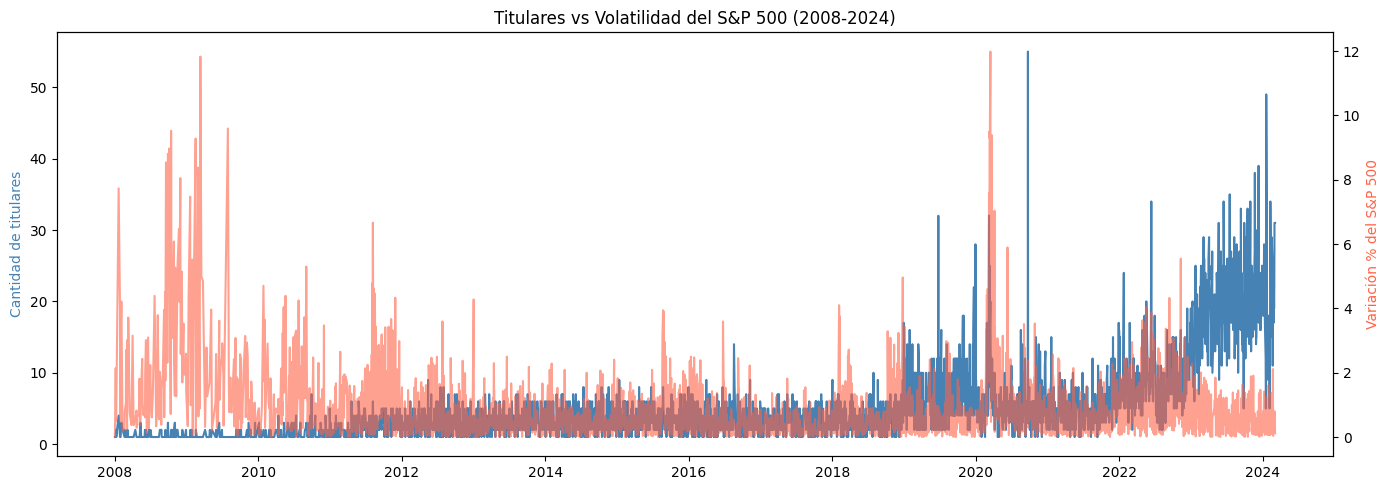

In [6]:
# Grafico la cantidad de titulares por día en todo el período
import matplotlib.pyplot as plt

# Calculo la cantidad de titulares por día
titulares_por_dia = df.groupby('Date')['Title'].count()

# Convierto el índice a formato fecha para que el eje x se vea bien
titulares_por_dia.index = pd.to_datetime(titulares_por_dia.index)

# Calculo el precio de cierre único por día (un solo valor por fecha)
precio_por_dia = df.groupby('Date')['CP'].mean()
precio_por_dia.index = pd.to_datetime(precio_por_dia.index)

# Calculo una medida de volatilidad (cambio porcentual diario del precio)
volatilidad = precio_por_dia.pct_change().abs() * 100

# Uno las dos series en un DataFrame para graficarlas juntas
comparacion = pd.DataFrame({
    'titulares': titulares_por_dia,
    'volatilidad': volatilidad
}).dropna()

# Grafico ambas series con dos ejes y porque tienen escalas muy distintas
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(comparacion.index, comparacion['titulares'], color='steelblue', label='Titulares')
ax1.set_ylabel('Cantidad de titulares', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(comparacion.index, comparacion['volatilidad'], color='tomato', alpha=0.6, label='Volatilidad (%)')
ax2.set_ylabel('Variación % del S&P 500', color='tomato')

plt.title('Titulares vs Volatilidad del S&P 500 (2008-2024)')
plt.tight_layout()
plt.show()

#### Análisis de la información disponible
👉 En promedio, hay 5 titulares por día.  
👉 Si se agrupan los titulares por día, el dataset se reduce a 3507 filas. 📰 **DECISIÓN**: se mantienen los titulares por separado para poder entrenar la red neuronal con más registros  
👉 La cobertura mediática (cantidad de titulares) crece a lo largo del período analizado. Esto no necesariamente quiere decir que hay más cobertura, sino que puede ser que la base de datos no capturó adecuadamente todos los registros.   
👉 En 2019 el crecimeinto en la cantidad de titulares es importante y en 2021 se establece un crecimiento sostenido.   
👉 A partir de 2019, se observan picos de cobertura cada vez más altos.  

# ETAPA 1: Procesamiento de Lenguaje Natural

In [7]:
# Verifico si hay valores nulos en el dataset
df.isnull().sum()

,0
Title,0
Date,0
CP,0


In [8]:
# Visualizo algunos de los titulares.

# La número 49
print(df.loc[50, 'Title'])
print("\n" + "-"*80)  # línea separadora


# La número 300
print(df.loc[301, 'Title'])
print("\n" + "-"*80)  # línea separadora


# La número 5000
print(df.loc[5001, 'Title'])
print("\n" + "-"*80)  # línea separadora

Futures Investing - Futures Contracts, Markets, Exchange

--------------------------------------------------------------------------------
The 15 Best Mutual Fund Managers Of Q1

--------------------------------------------------------------------------------
Despite Trump euphoria, Wall Street's 2017 forecast is the most bearish annual outlook in 12 years

--------------------------------------------------------------------------------


## 1.1 Normalización de texto  
Se define una función que:  
- Convierte todo el texto a minúsculas
- Mantenemos la referencia al índice S&P500 en el titular, en caso a futuro se requiera
- Reemplaza los guiones (-) por un espacio (" ") (por ejemplo en ""first-session-of-year" de la fila 1)
- Elimina los signos de puntuación o símbolos no alfanumérico
- Elimina los números, ya que no no aportan sentido positivo/negativo que ayueden a predecir la etiqueta de clasificación
- Elimina los espacios extras

In [9]:
# Importo la librería de regular expressions (busca, extrae partes y reemplaza texto)
import re  # Regex

# Función que limpia cada titular:
def limpiar_texto(texto):
    texto = texto.lower()                             # convierte a minúsculas
    texto = texto.replace('s&p 500', 'sandp')         # reemplazamos el nombre del índice por texto para preservarlo
    texto = texto.replace('s&p500', 'sandp')
    texto = texto.replace('-', ' ')                   # reemplazo guiones por espacios
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto)     # elimina signos de puntuación, caracteres especiales y números
                                                      # (a-zA-Z incluye todas las letras del alfabeto, por lo que se excluyen los números)
    texto = re.sub(r'\s+', ' ', texto).strip()        # elimina espacios extra (\s+ significa "uno o más espacios en blanco" y
                                                      #                        .strip() elimina espacios al principio o al final del texto)
    return texto

# Se aplica la función a cada fila de la columna Title
# Se guarda el resultado en una columna nueva
df['Title_clean'] = df['Title'].apply(limpiar_texto)

# Muestro algunas filas para verificar que la limpieza funcionó bien
df[['Title', 'Title_clean']].head(10)

,Title,Title_clean
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",jpmorgan predicts will be nothing but net
1,Dow Tallies Biggest First-session-of-year Poin...,dow tallies biggest first session of year poin...
2,2008 predictions for the S&P 500,predictions for the sandp
3,"U.S. Stocks Higher After Economic Data, Monsan...",us stocks higher after economic data monsanto ...
4,U.S. Stocks Climb As Hopes Increase For More F...,us stocks climb as hopes increase for more fed...
5,How Investing in Intangibles -- Like Employee ...,how investing in intangibles like employee sat...
6,Head And Shoulders Top Bodes Ill For Bulls,head and shoulders top bodes ill for bulls
7,U.S. Stocks Zigzag Higher As Bernanke Speech S...,us stocks zigzag higher as bernanke speech sin...
8,It's a Black Monday as stock markets tank in e...,its a black monday as stock markets tank in ev...
9,U.S. Stocks Largely Recover From Early Plunge,us stocks largely recover from early plunge


## 1.2 Tokenización y lematización

### Librería spaCy
Luego de limpiar el texto, se procede a:  
- *tokenizar* cada titular (se separan en unidades mínimas de significado: palabras o tokens)
- *lematizar* cada titular (se reduce la palabra a su forma base)
- *eliminar stopwords* (palabras frecuentes que no aportan significado)

Librería **spaCy**: en un solo paso tokeniza, elimina stopwords y lematiza. Es más eficiente que NLTK.  

 **Idioma inglés**: utilizamos el modelo `en_core_web_sm` de spaCy, entrenado específicamente para el idioma inglés, el cual está optimizado para textos del dominio general (adecuado para titulares de noticias financieras).   

Sólo se lematiza y **no se aplica stemming** porque es mejor tener las palabras de base real y así evitar palabras no reales que pierdan el significado financiero.

In [10]:
# Instalación del modelo
import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])

CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

In [11]:
# importo al librería
import spacy

# Cargo el modelo de inglés de spaCy
nlp = spacy.load('en_core_web_sm')

# Función que tokeniza, elimina stopwords y lematiza cada titular
def tokenizar_lematizar(texto):
    doc = nlp(texto)                          # spiCy crea un objeto 'doc' que contiene toda la info (tokens, leas, stopwords, etc).
    tokens = [token.lemma_ for token in doc   # Recorro cada token del doc y me quedo sólo con los que:
              if not token.is_stop and not token.is_space]  # NO son stopwords y NO son espacios (residuales xq ya limpié espacios en fn limpiar_texto)
    return tokens

# Aplico la función a cada fila de la columna limpia
df['tokens'] = df['Title_clean'].apply(tokenizar_lematizar)

# Muestro el resultado
df[['Title_clean', 'tokens']].head(10)

,Title_clean,tokens
0,jpmorgan predicts will be nothing but net,"[jpmorgan, predict, net]"
1,dow tallies biggest first session of year poin...,"[dow, tallies, big, session, year, point, drop]"
2,predictions for the sandp,"[prediction, sandp]"
3,us stocks higher after economic data monsanto ...,"[stock, high, economic, datum, monsanto, outlook]"
4,us stocks climb as hopes increase for more fed...,"[stock, climb, hope, increase, feed, move]"
5,how investing in intangibles like employee sat...,"[invest, intangible, like, employee, satisfact..."
6,head and shoulders top bodes ill for bulls,"[head, shoulder, bode, ill, bull]"
7,us stocks zigzag higher as bernanke speech sin...,"[stock, zigzag, higher, bernanke, speech, sink]"
8,its a black monday as stock markets tank in ev...,"[black, monday, stock, market, tank, corner, g..."
9,us stocks largely recover from early plunge,"[stock, largely, recover, early, plunge]"


### Librería NLTK
De forma paralela, se procesa el texto con la librería NLTK y comparo los resultados con la librería spaCy.

In [12]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
print("nltk ok")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


nltk ok


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Inicializo el lematizador y las stopwords en inglés de NLTK
lematizador = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Función que tokeniza, elimina stopwords y lematiza con NLTK
def tokenizar_lematizar_nltk(texto):
    # Tokenizo el texto dividiéndolo en palabras individuales
    tokens = word_tokenize(texto)
    # Filtro stopwords y lematizo cada token
    tokens = [lematizador.lemmatize(token) for token in tokens
              if token not in stop_words and token.isalpha()]
    return tokens

# Aplico la función al texto limpio y guardo en columna nueva
# Uso Title_clean para mantener consistencia con el pipeline de spaCy
df['tokens_nltk'] = df['Title_clean'].apply(tokenizar_lematizar_nltk)

# Comparo los resultados de ambas herramientas en las primeras 5 filas
comparacion = df[['Title_clean', 'tokens', 'tokens_nltk']].head(5)
comparacion.columns = ['Texto limpio', 'Tokens spaCy', 'Tokens NLTK']
comparacion

,Texto limpio,Tokens spaCy,Tokens NLTK
0,jpmorgan predicts will be nothing but net,"[jpmorgan, predict, net]","[jpmorgan, predicts, nothing, net]"
1,dow tallies biggest first session of year poin...,"[dow, tallies, big, session, year, point, drop]","[dow, tally, biggest, first, session, year, po..."
2,predictions for the sandp,"[prediction, sandp]","[prediction, sandp]"
3,us stocks higher after economic data monsanto ...,"[stock, high, economic, datum, monsanto, outlook]","[u, stock, higher, economic, data, monsanto, o..."
4,us stocks climb as hopes increase for more fed...,"[stock, climb, hope, increase, feed, move]","[u, stock, climb, hope, increase, fed, move]"


**Comparación de resultados**  

NLTK no lematizó correctamente:
| Ejemplo | spaCy | NLTK |
|---------|-------|------|
| "predicts" | "predict" ✅ | "predicts" ❌ |
| "biggest" | "big" ✅ | "biggest" ❌ |
| "higher" | "high" ✅ | "higher" ❌ |

De comparar los resultados de las dos librerías de lematizado y tokenizado, surge que spaCy produce tokens más limpios y lematizados con mayor precisión, por lo que se avanza con el output de esta spaCy para el resto del pipeline.

## 1.3 Nubes de palabras
Se elaboran 2 nubes de palabras para visualizar las palabras más frecuentes en los titulares separando los días en que el mercado (S&P500) **subió** de los días en que **bajó**. El objetivo es identificar visualmente si existe algún patrón en el vocabulario asociado a cada comportamiento del mercado.

### 1.3.1 Creación de la variable MERCADO
Primero se crea la **variable MERCADO** que indica el alza (1) o baja (0) del precio del índice respecto al día anterior.

In [14]:
# Ordeno el dataframe por fecha para calcular la variación diaria
df = df.sort_values('Date').reset_index(drop=True)

# Calculo el precio de cierre por día
# Como hay varios titulares por día con el mismo precio, elimino duplicados (en esta columna sólo necesito ver si subió o bajó el precio en el día)
df_precios = df[['Date', 'CP']].drop_duplicates(subset='Date').copy()

# Calculo la variación porcentual respecto al día anterior
df_precios['variacion'] = df_precios['CP'].pct_change()

# Creo la variable objetivo binaria: 1 si subió, 0 si bajó o se mantuvo
df_precios['mercado'] = (df_precios['variacion'] > 0).astype(int)

# Uno esta información al dataframe original
df = df.merge(df_precios[['Date', 'mercado']], on='Date', how='left')

# Verifico el resultado
df[['Date', 'CP', 'mercado']].head(10)

,Date,CP,mercado
0,2008-01-02,1447.16,0
1,2008-01-02,1447.16,0
2,2008-01-02,1447.16,0
3,2008-01-03,1447.16,0
4,2008-01-07,1416.18,0
5,2008-01-09,1409.13,0
6,2008-01-09,1409.13,0
7,2008-01-10,1420.33,1
8,2008-01-22,1310.50,0
9,2008-01-22,1310.50,0


In [15]:
# Verifico el tipo de datos de cada columna
print("\n" + "-"*80)  # línea separadora
print ("Tipos de datos")
print(df.dtypes)
print("\n" + "-"*80)  # línea separadora
# Verifico si quedaron nulos en la columna mercado
print ("Datos nulos en columna de cambio en CP")
print(df['mercado'].isnull().sum())
print("\n" + "-"*80)  # línea separadora
# Verifico cuántos valores hay de cada clase
print("Etiquetas variable MERCADO")
print(df['mercado'].value_counts())
print(df['mercado'].value_counts(normalize=True).round(2) * 100)  # normalize=True da las proporciones (que se multiplican *100 para obetener el %)
print("\n" + "-"*80)  # línea separadora
# Verifico cuántos días no tuvieron variación
print("Días con precios sin variacion")
print(df_precios['variacion'].eq(0).sum())
print("\n" + "-"*80)  # línea separadora
print("Días con precios con variacion casi nula (menor al 0.01%)")
print(df_precios['variacion'].abs().lt(0.0001).sum())


--------------------------------------------------------------------------------
Tipos de datos
Title           object
Date            object
CP             float64
Title_clean     object
tokens          object
tokens_nltk     object
mercado          int64
dtype: object

--------------------------------------------------------------------------------
Datos nulos en columna de cambio en CP
0

--------------------------------------------------------------------------------
Etiquetas variable MERCADO
mercado
1    10288
0     8839
Name: count, dtype: int64
mercado
1    54.0
0    46.0
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Días con precios sin variacion
1

--------------------------------------------------------------------------------
Días con precios con variacion casi nula (menor al 0.01%)
42


**Análisis de la variable MERCADO** (variable objetivo en el modelo ML):  
1. No existen valores nulos
2. Existe sólo un día sin variación de precios (queda etiquetada como 0)
3. Existen sólo 42 días con variación de precios casi nula (queda etiquetada como 0).
   > 2 y 3 representan menos del 0.2% del dataset, por lo que se conservan porque no tienen impacto significativo en el modelo
5. Clases balanceadas: 54% alzas vs 46% bajas del índice

In [16]:
# Librerías necesarias para las nubes de palabras
import subprocess
subprocess.run(["pip", "install", "wordcloud", "--break-system-packages"])
from wordcloud import WordCloud
import matplotlib.pyplot as plt
print("ok")

ok


### 1.3.2 Nubes con todas las palabras

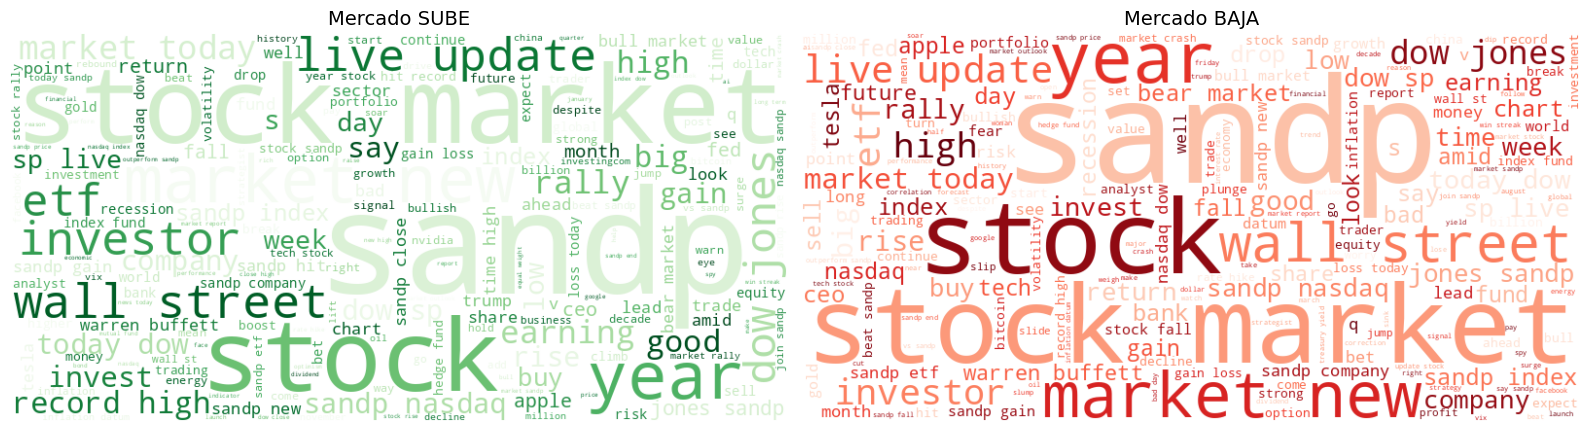

In [17]:
# Separo los tokens según el comportamiento del mercado
# Como la columna tokens es una serie de listas, explode() "desanida" esas listas y convierte cada elemento en una fila separada
tokens_sube = df[df['mercado'] == 1]['tokens'].explode()
tokens_baja = df[df['mercado'] == 0]['tokens'].explode()

# Convierto las listas de tokens a texto plano (WordCloud necesita un string)
# ' '.join() une todas las palabras en un solo string
# join no puede trabajar con listas anidadas, por eso arriba se desarmaron en una serie de palabras individuales
# después del explode() pueden quedar valores NaN sueltos. Se usa una list comprehension con un filtr en el join
texto_sube = ' '.join([t for t in tokens_sube if isinstance(t, str)])   # p/cada elemento t en tokens_sube, incluye solo si es una instancia de string
texto_baja = ' '.join([t for t in tokens_baja if isinstance(t, str)])

# Genero las nubes de palabras
wc_sube = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(texto_sube)
wc_baja = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_baja)

# Grafico las dos nubes una al lado de la otra
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.imshow(wc_sube, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('Mercado SUBE', fontsize=14)

ax2.imshow(wc_baja, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Mercado BAJA', fontsize=14)

plt.tight_layout()
plt.show()

### 1.3.3 Nubes con palabras filtradas  
Para visualizar mejor las palabras más específicas, filtro palabras propias del tema que no aportan a la diferenciación entre laza y baja.  
Palabras: sandp (el índice en sí mismo), stock, market, year, today, week, time, day, new.

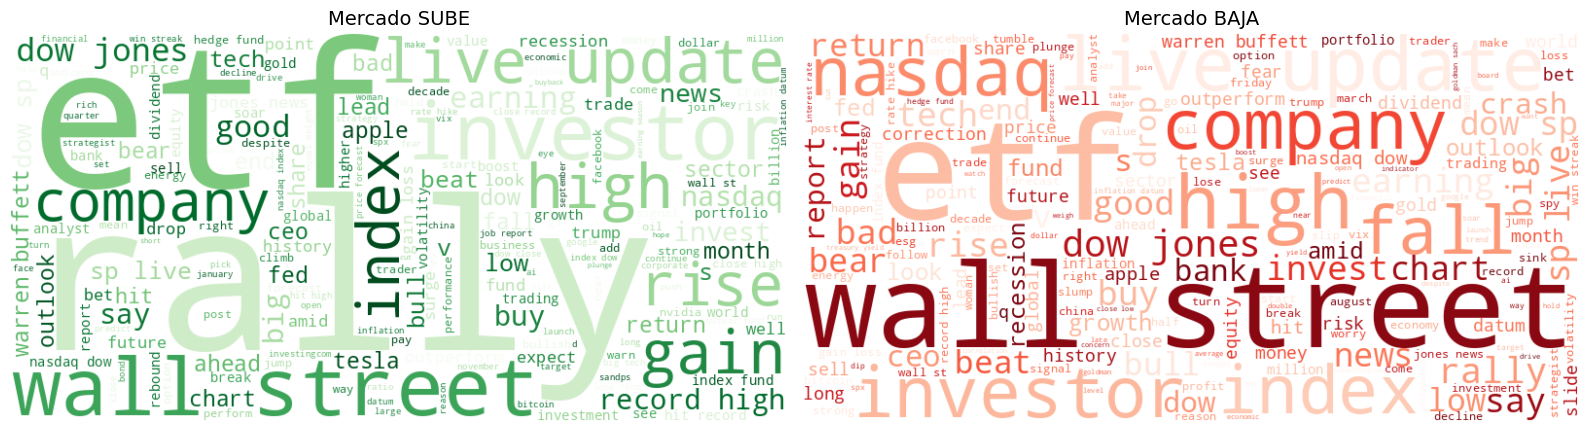

In [18]:
# Palabras que no aportan diferenciación entre subida y bajada
palabras_excluir = ['sandp', 'stock', 'market', 'year', 'today', 'week', 'time', 'day', 'new']

# Filtro los tokens excluyendo esas palabras
tokens_sube_filtrado = [t for t in tokens_sube if isinstance(t, str) and t not in palabras_excluir]
tokens_baja_filtrado = [t for t in tokens_baja if isinstance(t, str) and t not in palabras_excluir]

# Convierto a texto plano
texto_sube_filtrado = ' '.join(tokens_sube_filtrado)
texto_baja_filtrado = ' '.join(tokens_baja_filtrado)

# Genero las nubes filtradas
wc_sube = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(texto_sube_filtrado)
wc_baja = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_baja_filtrado)

# Grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.imshow(wc_sube, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('Mercado SUBE', fontsize=14)
ax2.imshow(wc_baja, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Mercado BAJA', fontsize=14)
plt.tight_layout()
plt.show()

#### Conclusión nubes de palabras por frecuencia absoltuta
Los titulares tienen vocabulario que se correlaciona con el comportamiento del índice, lo que justifica usar NLP para predecir la dirección del S&P 500.

### 1.3.4 Nubes con palabras diferenciadoras
En este apartado se crean las nubes tomando en cuenta las palabras **más diferenciadoras** entre clases, independientemente de su frecuencia absoluta (no son las más frecuentes).   
Para esto se calcula la diferencia proporcional de cada palabra entre ambas clases, lo que permite identificar::  
- Palabras que aparecen **solo en una clase** (exclusivas de mercado en alza o en baja)
- Palabras que aparecen en **ambas clases** pero con proporciones muy distintas — por ejemplo: "high", aparece en ambas pero proporcionalmente más cuando el mercado sube.

El resultado es una nube que refleja el vocabulario que más distingue un mercado en alza de uno en baja.

In [19]:
from collections import Counter

# Cuento frecuencia de cada palabra en cada clase
freq_sube = Counter(tokens_sube_filtrado)
freq_baja = Counter(tokens_baja_filtrado)

# Total de palabras en cada clase
total_sube = sum(freq_sube.values())
total_baja = sum(freq_baja.values())

# Calculo la diferencia proporcional entre clases
diferencia = {}
palabras = set(freq_sube.keys()) | set(freq_baja.keys())

for palabra in palabras:                                  # recorre cada palabra y calcula la diferencia
    prop_sube = freq_sube.get(palabra, 0) / total_sube
    prop_baja = freq_baja.get(palabra, 0) / total_baja
    diferencia[palabra] = prop_sube - prop_baja

# Ordeno y muestro las 15 más asociadas a SUBE y a BAJA
import pandas as pd
df_dif = pd.Series(diferencia).sort_values(ascending=False)   # Convierte el diccionario de diferencias en una Serie ordenada de mayor a menor

print("Top 15 palabras asociadas a MERCADO SUBE:")
print(df_dif.head(15))                                       # muestra las 15 con diferencia más positiva (más características de SUBE)
print("\nTop 15 palabras asociadas a MERCADO BAJA:")
print(df_dif.tail(15))                                       # muestra las 15 con diferencia más negativa (más características de BAJA)

Top 15 palabras asociadas a MERCADO SUBE:
high       0.006592
record     0.004504
rally      0.002837
gain       0.002106
earning    0.001810
higher     0.001643
hit        0.001587
close      0.001578
rise       0.001568
good       0.001395
surge      0.001023
climb      0.000889
trump      0.000778
nvidia     0.000744
jump       0.000730
dtype: float64

Top 15 palabras asociadas a MERCADO BAJA:
esg          -0.000911
bank         -0.000930
sink         -0.000937
loss         -0.000948
wall         -0.000995
tumble       -0.001019
fear         -0.001099
correction   -0.001103
plunge       -0.001139
bear         -0.001322
lower        -0.001634
low          -0.001960
bad          -0.002316
drop         -0.002372
fall         -0.003595
dtype: float64


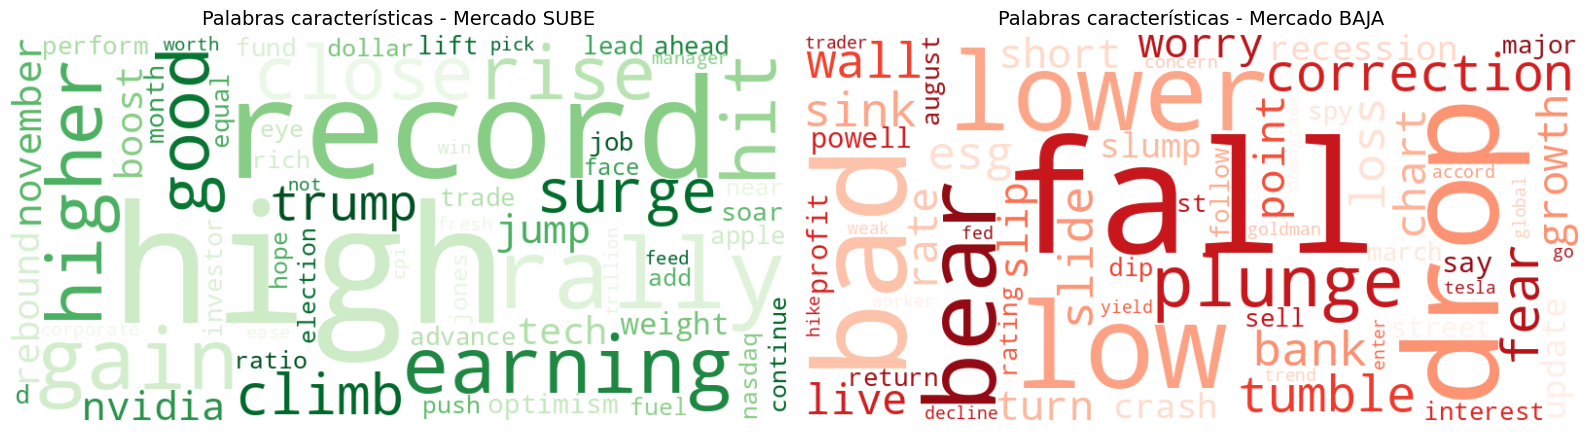

In [20]:
# Tomo las 50 palabras más asociadas a cada clase
palabras_sube = df_dif.head(60).to_dict()
palabras_baja = df_dif.tail(60).abs().to_dict()

# Genero las nubes usando frecuencias en vez de texto plano
wc_sube = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate_from_frequencies(palabras_sube)
wc_baja = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate_from_frequencies(palabras_baja)

# Grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.imshow(wc_sube, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('Palabras características - Mercado SUBE', fontsize=14)
ax2.imshow(wc_baja, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Palabras características - Mercado BAJA', fontsize=14)
plt.tight_layout()
plt.show()

#### Conclusión nubes de palabras diferenciadoras  
Las nubes de palabras diferenciadoras muestran una asociación clara entre el vocabulario de los titulares y el comportamiento del índice S&P 500.

En los días en que el mercado **subió**, predominan palabras como "record", "rally", "gain", "earning", "rise", "surge" y "boost" (con connotación positiva asociada a crecimiento y rendimiento favorable).

En los días en que el mercado **bajó**, predominan palabras como "fall", "drop", "loss", "correction", "bear", "tumble" y "crash" (con connotación negativa asociada a caídas y deterioro del mercado).

Este resultado sugiere que existe una relación entre el tono del lenguaje utilizado en los titulares financieros y la dirección del índice, lo que valida la hipótesis central del proyecto: el análisis de sentimiento de noticias financieras puede ser una señal útil para anticipar el comportamiento del índice S&P 500.

## 1.4 N-gramas

Para un análisis más profundo del texto de los titulares, se elaboran **bigramas** (secuencia de dos elementos consecutivos -letras, sílabas o palabras— extraídos de un texto o conjunto de datos-).  
Se elaboran bigramas y no secuencias de más elementos, dada la longitud de los textos de los titulares bajo análisis (secuencias de más elementos pueden tener baja frecuencia ya afecta al modelo de aprendizaje).

In [21]:
# Verifico librerías necesarias para N-gramas
from nltk import ngrams
print("nltk ok")

# Verifico librerías para análisis de sentimiento
from nltk.sentiment.vader import SentimentIntensityAnalyzer
print("vader ok")

nltk ok
vader ok


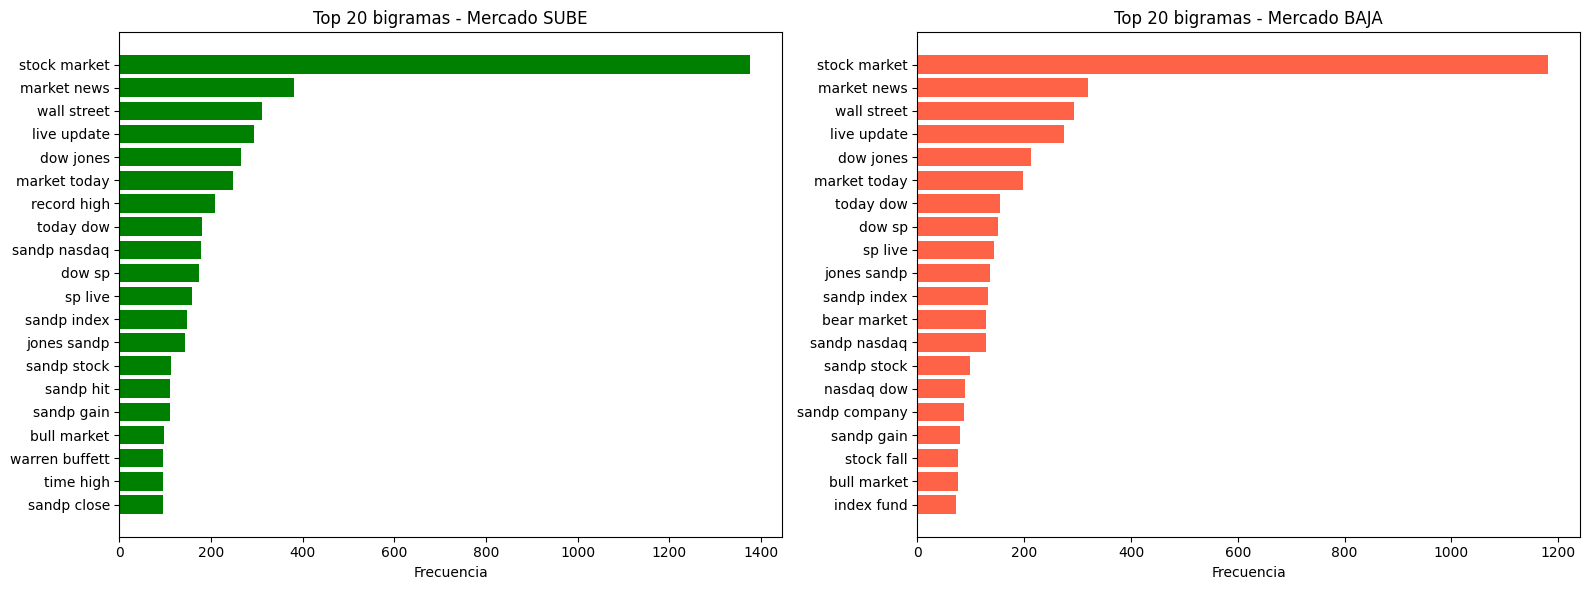

In [22]:
from nltk import ngrams
from collections import Counter
import matplotlib.pyplot as plt

# Función que genera bigramas a partir de una lista de tokens
def obtener_bigramas(lista_tokens):
    bigramas = []
    for tokens in lista_tokens:
        bigramas.extend(list(ngrams(tokens, 2)))
    return bigramas

# Genero bigramas separados por clase
bigramas_sube = obtener_bigramas(df[df['mercado'] == 1]['tokens'])
bigramas_baja = obtener_bigramas(df[df['mercado'] == 0]['tokens'])

# Cuento los más frecuentes en cada clase
top_sube = Counter(bigramas_sube).most_common(20)
top_baja = Counter(bigramas_baja).most_common(20)

# Grafico los bigramas más frecuentes por clase
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mercado SUBE
palabras_s = [f"{b[0]} {b[1]}" for b, _ in top_sube]
frecuencias_s = [f for _, f in top_sube]
ax1.barh(palabras_s[::-1], frecuencias_s[::-1], color='green')
ax1.set_title('Top 20 bigramas - Mercado SUBE')
ax1.set_xlabel('Frecuencia')

# Mercado BAJA
palabras_b = [f"{b[0]} {b[1]}" for b, _ in top_baja]
frecuencias_b = [f for _, f in top_baja]
ax2.barh(palabras_b[::-1], frecuencias_b[::-1], color='tomato')
ax2.set_title('Top 20 bigramas - Mercado BAJA')
ax2.set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

#### Conclusión bigramas por frecuencia
Los bigramas más frecuentes en ambas clases son similares, dado que son términos propios del tema.   

Luego, existen bigramas que aparecen en ambas clases, pero con distinta frecuencia, en consonancia con la connotación que tienen. Por ejemplo, "bear market (mercado bajista)" aparecen con mayor frecuencia en el mercado a la BAJA, mientras que "bull market (mercado alcista)" aparece con mayor frecuencia en el mercado ala SUBA.  

Dentro de los menos frecuentes (desde la mitad para abajo aproximadamente) aparecen bigramas específicos de cada clase que coinciden con la connotación que correpsonde (positiva/negativa):  
**SUBE**: "record high" — connotación positiva
**BAJA**:  "stock fall" — connotación negativa  

Con esto, vemos que los N-gramas de los titulares se relacionan con el comportamiento del mercado, además de las palabras individuales (análisis anterior). Estos también muestran patrones y por tanto aportan al análisis y justifica que los usemos como features del modelo.

## 1.5 Análisis de sentimiento - VADER

Aplico la técnica de NLP de análisis de sentimiento para identificar la carga emocional de los titulares, clasificándolos como **positivo**, **negativo** o **neutral**.

**Herramienta a autilizar**: **VADER** (Valence Aware Dictionary and sEntiment Reasoner).  
Razones:  
- Está optimizado para **textos cortos** (analiza específicamente sentimiento en textos cortos) como titulares de noticias y publicaciones en redes sociales.  
- VADER funciona mediante un diccionario de palabras con **puntajes de sentimiento predefinidos**, el caula aplica directamente sobre el texto ->. No requiere entrenamiento previo. En nuestro caso, palabras como "gain" o "rally" tienen puntaje positivo, mientras que "fall" o "crash" tienen puntaje negativo.
- Devuelve un **score compuesto** entre -1 (muy negativo) y +1 (muy positivo), lo que permite tanto clasificar como cuantificar el sentimiento

A partir de ese score, cada titular se clasifica como:
- **Positivo:** score ≥ 0.05
- **Negativo:** score ≤ -0.05
- **Neutral:** entre -0.05 y 0.05

In [23]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Descargo el diccionario de VADER si no está disponible
nltk.download('vader_lexicon')

# Inicializo el analizador
sia = SentimentIntensityAnalyzer()

# Aplico VADER a cada titular limpio y extraigo el score compuesto
   # El score compuesto va de -1 (muy negativo) a +1 (muy positivo)
df['sentiment_score'] = df['Title_clean'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Clasifico cada titular según el score
   # Positivo: score >= 0.05
   # Negativo: score <= -0.05
   # Neutral: entre -0.05 y 0.05
def clasificar_sentimiento(score):
    if score >= 0.05:
        return 'positivo'
    elif score <= -0.05:
        return 'negativo'
    else:
        return 'neutral'

df['sentimiento'] = df['sentiment_score'].apply(clasificar_sentimiento)

# Verifico la distribución
print("\n" + "-"*80)  # línea separadora
print("Recuento de sentimientos por puntaje")
print(df['sentimiento'].value_counts())
print("\n" + "-"*80)  # línea separadora
print("Recuento de sentimientos por puntaje - En %")
print(df['sentimiento'].value_counts(normalize=True).round(2) * 100)
print("\n" + "-"*80)  # línea separadora

# Cruzo sentimiento con comportamiento del mercado y muestro en tabla
print("Sentimiento en relación con variable mercado")
tabla = pd.crosstab(df['sentimiento'], df['mercado'], normalize='index').round(2) * 100
tabla.columns = ['Mercado BAJA (%)', 'Mercado SUBE (%)']
tabla.index.name = 'Sentimiento'
tabla
print("\n" + "-"*80)  # línea separadora

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...



--------------------------------------------------------------------------------
Recuento de sentimientos por puntaje
sentimiento
neutral     9205
positivo    5577
negativo    4345
Name: count, dtype: int64

--------------------------------------------------------------------------------
Recuento de sentimientos por puntaje - En %
sentimiento
neutral     48.0
positivo    29.0
negativo    23.0
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Sentimiento en relación con variable mercado

--------------------------------------------------------------------------------


#### Conclusión del análisis de sentimiento
- Casi la mitad de los titulares no tienen carga emocional clara y por tanto se las clasifica como neutral. Esto es esperable en titulares de diarios que se limitan muchas veces a informar y describir.  
- En relación con la variable que mide si el índice S&P500 (`mercado`) sube o baja:   
    | Sentimiento | Mercado BAJA (%) | Mercado SUBE (%) | Interpretación |
|-------------|-----------------|-----------------|------------------------------|
| Negativo    | 52%             | 48%             | Se asocia más a días de baja  (58%)|
| Neutral     | 46%             | 54%             | Leve tendencia a días de suba (54%). Resultados en el medio del valor de cada categoría|
| Positivo    | 42%             | 58%             | Se asocia más a días de suba (58%)|
  
Se observa un poder predictivo aunque **parcial**, ya que los titulares negativos no siempren coinciden con una baja del índice y viceversa.  
Asimismo, la tendencia es clara y justifica el uso del sentimiento como variable predictiva en el modelo.

## 1.6 Conclusiones Etapa 1: Procesamiento de Lenguaje Natural (NLP)

A continuación se resumen los principales hallazgos generados a partir de las distintas técnicas de NLP aplicadas sobre los titulares de noticias financieras del dataset a lo largo de la Etapa 1:

| Técnica | Hallazgo  |
|--------|-------------------|
| **Análisis exploratorio** | El volumen de cobertura mediática creció significativamente desde 2019, con picos que coinciden con eventos de alta volatilidad como el COVID-19 |
 **Limpieza y tokenización** | Se normalizó el texto eliminando símbolos, números y stopwords, y se lematizaron las palabras. Se preservó "S&P 500" como token "sandp" dado su relevancia en el dominio |
| **Nubes de palabras** | Las nubes generales muestran vocabulario propio del dominio financiero (S&P, market, stock). Al filtrar por palabras diferenciadoras, surgen patrones claros: términos como "rally", "gain" y "record" se asocian a días de suba, mientras que "fall", "drop" y "bear" se asocian a días de baja |
| **N-gramas** | Los bigramas más frecuentes son compartidos entre ambas clases ("stock market", "wall street"), pero aparecen bigramas exclusivos con connotación clara: "record high" y "sandp gain" en días de suba, y "bear market" en días de baja |
| **Análisis de sentimiento** | VADER clasifica el 48% de los titulares como neutrales, 29% como positivos y 23% como negativos. Al cruzar con la variable objetivo, los titulares positivos se asocian a días de suba (58%) y los negativos a días de baja (52%).  |

**Conclusión general**

El análisis confirma que existe una relación entre el lenguaje utilizado en los titulares financieros y el comportamiento del S&P 500.  
Si bien la señal no es perfecta en el **análisis de sentimiento**, debe tenerse en cuenta que los mercados no son fácilmente predecibles y VADER no fue entrenado específicamente en textos financieros. No obstante, la tendencia es consistente y justifica avanzar hacia la construcción de un modelo de clasificación en la Etapa 2.   

# ETAPA 2 - Vectorización y modelo

### 2.1 TF-IDF (Term Frequency - Inverse Document Frequency)

Convertimos en números el texto para que el modelo de ML pueda procesarlo.   
**Técnica de vectorización**: **TF-IDF**, que asigna un puntaje a cada palabra según dos criterios:

- **TF:** qué tan frecuente es la palabra dentro de un titular específico
- **IDF:** qué tan rara es esa palabra en el conjunto total de titulares — penaliza las palabras que aparecen en casi todos los titulares y que por lo tanto no aportan información diferenciadora

El resultado es una **matriz numérica** donde cada fila representa un titular y cada columna representa una palabra del vocabulario (que va a incluir todas las palabras o tokens de todos los titulares). Las palabras con puntaje alto son las que mejor caracterizan cada titular en particular.

Esta matriz es la que se utilizará como entrada al modelo de clasificación para predecir si el mercado subió o bajó.  

**Limitación**:  el hecho de que los titulares sean cortos afecta al modelo, ya que TF-IDF funciona mejor con textos largos (hay más palabras para calcular frecuencias). Con titulares cortos muchos puntajes quedan bajos o iguales.

**Pregunta de reflexión: ¿Por qué usamos TF-IDF en lugar de solo contar palabras (CountVectorizer)?**
CountVectorizer trata todas las palabras por igualmientras que TF-IDF penaliza las más frecuentes del corpus, ya que no aportan información diferenciadora. En este dataset financiero, por ejemplo, palabras como "market" o "stock" aparecen en casi todos los titulares, por lo que TF-IDF es más adecuado porque destaca las palabras que realmente distinguen un titular de otro.

In [24]:
# Importo las librerías necesarias para la Etapa 2
import numpy as np
# Vectorización para ML
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
print("sklearn vectorización ok")
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
print("sklearn modelo ok")

# Deep Learning
import tensorflow as tf
print("tensorflow ok")

sklearn vectorización ok
sklearn modelo ok
tensorflow ok


#### Preparación del texto para TF-IDF
Convertimos la columna `tokens` — que contiene listas de palabras — de vuelta a un string, ya que TF-IDF de sklearn espera texto plano como entrada y realiza su propia tokenización diviendo por espacios.

Como input de TF-IDF, no uso la columna `Title_clean` que se usó para VADER porque contiene stopwords.  
Se genera una nueva columna `Title_tokens_str` a partir de `tokens` que incorpora todo el preprocesamiento realizado (texto limpio, sin stopwords y lematizado), y crea un vocabulario más compacto y representativo (palabras como "falling", "fell" y "falls" quedan unificadas como "fall", y palabras vacías como "the" o "is" no ocupan espacio en la matriz).

In [25]:
# Convierto los tokens lematizados de vuelta a string para usar con TF-IDF
# El texto incorpora el preprocesamiento ya hecho (limpieza + stopwords + lematización)
df['Title_tokens_str'] = df['tokens'].apply(lambda x: ' '.join(x))

In [26]:
# Inicializo el vectorizador TF-IDF
# max_features: limito el vocabulario a las 5000 palabras más frecuentes
# ngram_range: incluyo unigramas y bigramas para capturar frases como "bear market"
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Ajusto el vectorizador al texto lematizado y sin stopwords
# El resultado es una matriz donde cada fila es un titular y cada columna una palabra
X = tfidf.fit_transform(df['Title_tokens_str'])

# Muestro las dimensiones de la matriz resultante
print(f"Dimensiones de la matriz TF-IDF: {X.shape}")
print(f"Cada titular quedó representado por {X.shape[1]} features")

# Muestro un ejemplo de cómo quedó vectorizado el primer titular
print(f"\nTitular original: {df['Title_tokens_str'][0]}")
print(f"Primeros 10 valores del vector: {X[0, :10].toarray()}")

# Muestro algunas palabras del vocabulario generado
print(f"\nAlgunas palabras del vocabulario (primeras 20 en orden alfabético):")
print(tfidf.get_feature_names_out()[:20])

Dimensiones de la matriz TF-IDF: (19127, 5000)
Cada titular quedó representado por 5000 features

Titular original: jpmorgan predict net
Primeros 10 valores del vector: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

Algunas palabras del vocabulario (primeras 20 en orden alfabético):
['aaa' 'aapl' 'ab' 'accelerate' 'accept' 'access' 'accord' 'account'
 'accurate' 'achieve' 'ackman' 'acquisition' 'act' 'action' 'active'
 'active fund' 'active manager' 'active trader' 'active vs' 'actively']


#### Resultado de la vectorización TF-IDF
Dimensiones de la matriz resultante: **(19.127 x 5.000)** (cada uno de los 19.127 titulares quedó representado como un vector de 5.000 valores numéricos — uno por cada palabra o bigrama del vocabulario (features).

Ejemplo de cómo se lee un vector (primer titular):

- **Texto:** `jpmorgan predict net`
- **Vector (primeras 10 posiciones):** `[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]`

Todos los valores son cero porque las primeras 10 palabras del vocabulario ("aapl", "ab", "accelerate"...) no aparecen en ese titular. Las únicas posiciones con valor distinto de cero serían las correspondientes a "jpmorgan", "predict" y "net" — las 3 palabras que sí contiene.

Esto se conoce como **matriz sparse**: la mayoría de los valores son cero porque cada titular corto solo contiene unas pocas palabras de las 5.000 posibles. Es una característica típica de TF-IDF aplicado a textos cortos como titulares de noticias.

### 2.2 Modelo de Machine Learning
Con el texto ya vectorizado, entreno un **modelo de ML de de aprendizaje supervisado de clasificación** que aprenda a predecir si el mercado va a subir (1) o bajar (0) a partir del contenido de los titulares.  

**Modelo de clasificación seleccionado: REGRESIÓN LOGÍSTICA**.
Es un modelo de clasificación que busca predecir la probabilidad de que una observación pertenezca a una clase u otra (en este caso, si el mercado sube (1) o baja (0)).

El modelo calcula para cada vector la probabilidad de que sea 1 o 0.  Toma todos los valores del vector TF-IDF de cada titular (las 5000 posiciones) y los multiplica por su peso correspondiente para sumar todo junto en un único número (combinación lineal), al cual se le aplica una **función sigmoide** (porque son 2 clases), que lo transforma en una probabilidad entre 0 y 1 (por defecto el umbral es 0.5, adecuado para clases balanceadas):

- Si la probabilidad resultante es **mayor a 0.5** → el modelo predice que el mercado **sube**
- Si la probabilidad resultante es **menor a 0.5** → el modelo predice que el mercado **baja**

Durante el entrenamiento, el modelo ajusta los pesos de cada palabra para minimizar los errores de predicción.  

Flujo: vector TF-IDF → combinación lineal → sigmoide → probabilidad → decisión (0 o 1)

**Resultado esperado de la regresión logística:**
- palabras como "gain" tendrán pesos positivos altos (por ej, 2.5)  
- palabras como "fall" o "crash" tendrán pesos negativos altos (por ej, -1.9)  

**Razones de la elección del modelo de regresión logísctica:**
- Es más adecuado para trabajar con matrices sparse como la que genera TF-IDF
- Es interpretable: permite identificar qué palabras tienen mayor peso en la predicción
- Es eficiente computacionalmente con datasets del tamaño del utilizado
- Es el modelo de referencia estándar (*baseline*) en tareas de clasificación de texto antes de avanzar hacia modelos más complejos
  
**Pasos a seguir:**
1. Dividir el dataset en conjunto de entrenamiento y de prueba
2. Entrenar el modelo con el conjunto de entrenamiento
3. Evaluar su performance con el conjunto de prueba mediante métricas de clasificación

In [27]:
from sklearn.model_selection import train_test_split

# X = matriz numérica (19.127 x 5.000) que surgió de vectorizar Title_tokens_str con TF-IDF
# y = variable objetivo (0 = mercado baja, 1 = mercado sube)

# Defino la variable objetivo
y = df['mercado']

# Divido los datos en conjunto de entrenamiento (aprende con el 80%) y prueba (evalúa con el 20%)
# random_state=42 asegura que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (15301, 5000)
Tamaño del conjunto de prueba: (3826, 5000)


In [28]:
# Inicializo el modelo de Regresión Logística
# max_iter=1000 aumenta el límite de iteraciones para asegurar la convergencia (cuando los pesos dejan de cambiar entre iteraciones)
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

# Entreno el modelo con el conjunto de entrenamiento
# Le paso la matriz TF-IDF (X_train) y las etiquetas reales (y_train)
modelo_lr.fit(X_train, y_train)

# Genero las predicciones sobre el conjunto de prueba
y_pred = modelo_lr.predict(X_test)

# Evalúo el modelo con métricas de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.43      0.49      1788
           1       0.59      0.71      0.64      2038

    accuracy                           0.58      3826
   macro avg       0.58      0.57      0.57      3826
weighted avg       0.58      0.58      0.57      3826



#### Métricas de evaluación del modelo

Para evaluar el rendimiento del modelo se utilizan las siguientes métricas:

| Métrica | Definición | Interpretación |
|---------|-----------|---------------------|
| **Precision** | De todos los que el modelo predijo como clase X, ¿cuántos eran realmente clase X? | De cada 100 subidas predichas, 59 eran realmente subidas |
| **Recall** | De todos los que realmente eran clase X, ¿cuántos detectó el modelo? | **Sube:** de cada 100 subidas reales (2.038), el modelo detectó 70 <br> **Baja:** de cada 100 bajadas reales (1.788), el modelo detectó 45 |
| **F1-score** | Balance entre precision y recall. Es la métrica resumen más útil por clase | 0.64 para subidas, 0.50 para bajadas |
| **Accuracy** | De todos los casos, ¿qué proporción clasificó correctamente? | El modelo acertó el 58% de los casos (levemente superior al azar)|
| **Macro avg** | Promedio simple de las métricas entre ambas clases, sin importar cuántos casos tiene cada una | Trata a ambas clases por igual |
| **Weighted avg** | Promedio ponderado por la cantidad de casos de cada clase | Le da más peso a la clase con más casos |

**Análisis de los resultados de las métricas**
El modelo de Regresión Logística alcanzó una **accuracy del 58%**, lo que significa que acierta levemente mejor que el azar (50%).
Si bien el resultado no es excepcional, es consistente con lo esperado para este tipo de problema dadas las limitaciones que enfrenta.

**Limitaciones del modelo:**  
👉 Los mercados financieros son difíciles de predecir dado que son **muy volátiles y sensibles a las expectativas de los agentes** del mercado (si un modelo simple pudiera predecirlos con alta precisión, todos lo usarían y la señal desaparecería).  
👉 **VADER no fue entrenado específicamente en textos financieros**, lo que limita la calidad del análisis de sentimiento  
👉 Los titulares son **textos cortos**, lo que genera vectores TF-IDF muy *sparse* con poca información por fila  
👉 El dataset muestra un **sesgo temporal** (en el período 2008-2015 la cobertura de noticias fue menor) lo que puede afectar la representatividad del modelo para períodos de alta volatilidad  
👉 Hay 42 **días con variación de precio casi nula** que quedaron etiquetados como bajada (0), lo que puede introducir algo de ruido en la variable objetivo  
👉 Existen **múltiples titulares por día que fueron tratados como observación independiente**. Siendo que varios titulares del mismo día comparten el mismo resultado de mercado, esto puede introducir dependencia entre observaciones (autocorrelación). Esto implica que el modelo asocia ciertas palabras a la baja por aparecer muchas veces ese día y no porque sean realmente predictivas. Se decidió trabajar con los titulares de forma independiente para preservra la cantida de filas necesarias para entrenar el modelo.  
👉 Puede existir **desfase temporal entre la publicación y el precio de cierre del índice** (un titular de un día determinado se asocia al precio de cierre de ese día, pero la noticia puede haberse publicado después del cierre del mercado o tener impacto real a un plazo diferido según la normativa, generando una asociación incorrecta)

**Performance por clase:**   
El modelo detecta mejor las **subidas** (recall 0.70) que las **bajadas** (recall 0.45), lo que sugiere que el vocabulario asociado a días alcistas es más distintivo y consistente que el vocabulario asociado a días bajistas.

**Aporte a la hipótesis:**   
A pesar de las limitaciones, el resultado valida la hipótesis del proyecto: **existe una señal en el lenguaje de los titulares financieros que permite anticipar, de forma parcial, el comportamiento del S&P 500**.

### 2.3 Modelo de Deep Learning (MLP)

**Text to Sequence + Red Neuronal**

A fin de mejorar el modelo de clasificación, se utiliza **Deep Learning** mediante una red neuronal entrenada sobre secuencias de texto (`Text to sequence`).

**Diferencia con TF-IDF**: TF-IDF representa cada titular como un vector de frecuencias sin considerar el orden de las palabras, mientras que **Text to Sequence** convierte cada titular en una secuencia de números enteros, donde cada número representa una palabra del vocabulario en un orden determinado. Esto permite que la red neuronal aprenda patrones considerando el orden en que aparecen las palabras.

**Pasos del proceso:**

1. **Tokenización:** se asigna un número entero único a cada palabra del vocabulario. Por ejemplo: "market" → 1, "fall" → 2, "rally" → 3
2. **Text to Sequence:** cada titular se convierte en una secuencia de esos números. Por ejemplo: "market fall" → [1, 2]
3. **Padding:** como los titulares tienen distinta longitud, se igualan agregando ceros al final para que todas las secuencias tengan el mismo largo


**Herramienta a utilizar para implementar el proceso:** se utiliza **Keras Tokenizer**, una clase de la librería Keras que asigna un número entero único a cada palabra del vocabulario y convierte cada titular en una secuencia de esos números mediante el método `text_to_sequences`. Finalmente, `pad_sequences` iguala el largo de todas las secuencias agregando ceros.  

**Resultado:** una matriz numérica que se utiliza como entrada a una **red neuronal densa (MLP - (Multi Layer Perceptron)**, que aprende a predecir si el mercado sube o baja a partir de esas secuencias.

**Arquitectura de la Red neuronal MLP (Multi Layer Perceptron)**  
Esta red neuronal (de las más simples) tiene 3 tipos de capas:  
1. **Embedding**: Convierte cada número entero de la secuencia en un vector denso de valores continuos
2. **Capas Dense (ocultas)**: Capas intermedias donde la red aprende patrones (cada neurona recibe todos los valores de la capa anterior, los combina y los transforma). Se usa la función de activación **ReLU** (estándar para capas ocultas).
3. **Capa de salida**: Una sola neurona con activación **sigmoide** (como en la Regresión Logística) que devuelve una probabilidad entre 0 y 1 para predecir suba o baja.

#### 2.3.1 Vectorización de secuencias (Text to Sequence)

In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Defino el tamaño máximo del vocabulario
# Solo considero las 5000 palabras más frecuentes (como en TF-IDF)
vocab_size = 5000

# Defino el largo máximo de cada secuencia
# Los titulares son cortos, con 20 palabras es suficiente para cubrir la mayoría
max_length = 20

# Creo el tokenizador y le indico el tamaño máximo del vocabulario
# oov_token='<OOV>' maneja palabras desconocidas que no estaban en el vocabulario
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')  # reemplaza palabras desconocidas por token especial <OOV>"

# Entreno el tokenizador con el texto limpio y lematizado
# Aprende el vocabulario y asigna un número entero a cada palabra
tokenizer.fit_on_texts(df['Title_tokens_str'])   # usa el string que surge de TF-IDF

# Convierto cada titular en una secuencia de números enteros
sequences = tokenizer.texts_to_sequences(df['Title_tokens_str'])

# Igualo el largo de todas las secuencias agregando ceros al final
# padding ->'post' agrega los ceros al final de cada secuencia
X_dl = pad_sequences(sequences, maxlen=max_length, padding='post')

# Muestro las dimensiones de la matriz resultante
print(f"Dimensiones de la matriz: {X_dl.shape}")

# Muestro un ejemplo del titular original y su secuencia de números
print(f"\nTitular original: {df['Title_tokens_str'][0]}")
print(f"Secuencia de números: {sequences[0]}")
print(f"Secuencia con padding: {X_dl[0]}")

Dimensiones de la matriz: (19127, 20)

Titular original: jpmorgan predict net
Secuencia de números: [403, 248, 588]
Secuencia con padding: [403 248 588   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]


#### 2.3.2 División en conjuntos de entrenamiento y prueba

In [30]:
# Defino la variable objetivo
y_dl = df['mercado'].values

# Divido los datos en conjunto de entrenamiento (80%) y prueba (20%)
# Uso el mismo random_state=42 para que la división sea comparable con el modelo anterior
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train_dl.shape}")
print(f"Tamaño del conjunto de prueba: {X_test_dl.shape}")

Tamaño del conjunto de entrenamiento: (15301, 20)
Tamaño del conjunto de prueba: (3826, 20)


El conjunto de entrenamiento y de prueba quedó con la misma cantidad de filas que en TF-IDF sólo que cada titular está representado por una secuencia de 20 números en lugar de 5000.   

La matriz resultado `X_dl` es el insumo de la red neuronal.  
`X_train_dl` → entra a la red durante el entrenamiento  
`X_test_dl` → entra a la red durante la evaluación

#### 2.3.3 Construcción de la red neuronal

In [31]:
# CONSTRUCCIÓN DE LA RED NEURONAL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

# Defino la dimensión del embedding
# Cada palabra se va a representar como un vector de 16 valores (p/textos cortos, dataset pequeño → embedding_dim chico (16, 32))
embedding_dim = 16  # va a agenerar una matriz de 20 x 16
                    # 20 filas (una por posición del titular - max_length) por 16 columnas (valores del embedding de cada palabra)

# Construyo la arquitectura de la red neuronal
modelo_dl = Sequential([

    # Capa Embedding: convierte cada número entero en un vector denso (sin valores cero)
    # vocab_size: tamaño del vocabulario
    # embedding_dim: dimensión del vector de cada palabra
    # input_length: largo de cada secuencia (20 palabras)
    Embedding(vocab_size, embedding_dim),

    # Flatten: convierte la matriz de embeddings en un vector plano
    # para poder pasarla a las capas Dense
    Flatten(),

    # Primera capa oculta con 64 neuronas y activación ReLU
    Dense(64, activation='relu'),

    # Segunda capa oculta con 32 neuronas y activación ReLU
    Dense(32, activation='relu'),

    # Capa de salida con 1 neurona y activación sigmoide
    # Devuelve una probabilidad entre 0 y 1
    Dense(1, activation='sigmoid')
])

# Compilo el modelo definiendo:
# - optimizer: algoritmo de optimización para ajustar los pesos
# - loss: función de pérdida para clasificación binaria
# - metrics: métrica a monitorear durante el entrenamiento
modelo_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Muestro el resumen de la arquitectura
modelo_dl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### 2.3.4 Entrenamiento de la red neuronal

In [32]:
# ENTRENAMIENTO DE LA RED NEURONAL
# epochs: cantidad de veces que el modelo recorre todo el dataset para ajustar los pesos
# validation_split: reservo el 20% del entrenamiento para validar en cada epoch
# batch_size: cantidad de titulares que procesa antes de actualizar los pesos
historia = modelo_dl.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    validation_split=0.2, # entrena con el 80% de X_train_dl
    batch_size=32    # no procesa todos los titulares a la vez: los divide en grupos de 32 y actualiza los pesos después de c/grupo
)

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5472 - loss: 0.6871 - val_accuracy: 0.5518 - val_loss: 0.6917
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6902 - loss: 0.5920 - val_accuracy: 0.5642 - val_loss: 0.7174
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8104 - loss: 0.4103 - val_accuracy: 0.5570 - val_loss: 0.8501
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8751 - loss: 0.2855 - val_accuracy: 0.5645 - val_loss: 0.9831
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9065 - loss: 0.2192 - val_accuracy: 0.5554 - val_loss: 1.1500
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9257 - loss: 0.1761 - val_accuracy: 0.5671 - val_loss: 1.2898
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9342 - loss: 0.1494 - val_accuracy: 0.5648 - val_loss: 1.5607
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9438 - loss: 0.1276 - val_accuracy: 

##### Resultados del entrenamiento
- el **accuracy** alcanza un valor de 0.95: el modelo aprende muy bien los datos de entrenamiento
- el **val_accuracy** crece hasta 0.5662 en la época 4 y luego baja sin recuperar ese valor: el modelo no logra generalizar a datos nuevos --> **overfitting**. Esperable en un dataset con textos cortos, ya que se dificulta que la red neuronal encuentre patrones lo necesariamente robustospara poder generalizar.

Dado que el modelo sobreajusta, se aplica **Early Stopping**: técnica que detiene el entrenamiento automáticamente cuando la métrica de validación deja de mejorar, evitando que el modelo siga memorizando los datos de entrenamiento innecesariamente.

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping: detiene el entrenamiento cuando val_loss deja de mejorar
# patience=3: espera 3 épocas sin mejora antes de detener el entrenamiento
# restore_best_weights=True: restaura los pesos de la mejor época al finalizar
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Reconstruyo el modelo desde cero para partir de pesos aleatorios
modelo_dl = Sequential([
    Embedding(vocab_size, embedding_dim),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entreno el modelo con early stopping
historia = modelo_dl.fit(
    X_train_dl, y_train_dl,
    epochs=20,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping]   # early stopping como parámetro en el fit
)

Epoch 1/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5435 - loss: 0.6889 - val_accuracy: 0.5622 - val_loss: 0.6827
Epoch 2/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6667 - loss: 0.6139 - val_accuracy: 0.5652 - val_loss: 0.7081
Epoch 3/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8053 - loss: 0.4243 - val_accuracy: 0.5645 - val_loss: 0.8487
Epoch 4/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8738 - loss: 0.2945 - val_accuracy: 0.5586 - val_loss: 0.9759


##### Resultados del entrenamiento con early stopping
- El entrenamiento se detuvo en la época 4, cuando empieza a observarse **overfitting**, al igual que en el paso anterior (entrenamiento sin early stopping).
- El menor val_loss se da en la época 1, por lo que el modelo restaura esos pesos en la evaluación del conjunto de pruebas.

#### 2.3.4 Evaluación del modelo

In [34]:
# Evalúo el modelo en el conjunto de prueba
# El modelo usa internamente los pesos de la época 1 (restore_best_weights=True) según el paso anterior
# umbral de decisión 0.5 (por la función sigmoide con probabilidades continuas entre 0 (baja) y 1 (sube).
y_pred_dl = (modelo_dl.predict(X_test_dl) > 0.5).astype(int)

# Muestro las métricas de clasificación
print(classification_report(y_test_dl, y_pred_dl))

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.53      0.43      0.47      1788
           1       0.57      0.66      0.61      2038

    accuracy                           0.55      3826
   macro avg       0.55      0.55      0.54      3826
weighted avg       0.55      0.55      0.55      3826



##### Análisis del modelo de red neuronal
- El **accuracy** es bajo y es hasta menor que en la  Regresión Logística (la red neuronal no predice mejor)
- Se observa **sesgo de lcase**: el modelo aprendió a predecir mejor las subas (recall muy alto) que las bajas (a las cuales casi no detecta: recall muy bajo)

| Métrica | Definición | Regresión Logística | Red Neuronal (MLP) |
|---------|-----------|--------------------|--------------------|
| **Accuracy** | De todos los casos, ¿qué proporción clasificó correctamente? | 0.58 | 0.55 |
| **Precision (sube)** | De todos los que predijo como subida, ¿cuántos eran realmente subidas? | 0.59 | 0.54 |
| **Precision (baja)** | De todos los que predijo como bajada, ¿cuántos eran realmente bajadas? | 0.57 | 0.67 |
| **Recall (sube)** | De cada 100 subidas reales (2.038), ¿cuántas detectó el modelo? | 70 | 97 |
| **Recall (baja)** | De cada 100 bajadas reales (1.788), ¿cuántas detectó el modelo? | 45 | 7 |
| **F1-score (sube)** | Balance entre precision y recall para subidas | 0.64 | 0.70 |
| **F1-score (baja)** | Balance entre precision y recall para bajadas | 0.50 | 0.12 |

**Conclusión**:   
- el modelo presenta **overfitting** (se ve en el entrenamiento)
- el modelo tiene un **sesgo de clase** (se ve en las métricas como el recall)

Por tanto, el modelo no es adecuado en la práctica. En términos de consumo de recursos, conviene utilizar la Regresión Logística.

#### 2.3.5 Ajustes al modelo

Para corregir el sesgo de clase, se implementan dos técnicas:  
- se agrega **Dropout**, que reduce el overfitting "apagando" neuronas aleatoriamente durante el entrenamiento
- se agrega **class_weight**, que penaliza más los errores en la clase minoritaria (bajadas)

Antes del dropout, se agrega **Batch Normalization** entre las capas Dense del modelo ajustado. Esta técnica, que normaliza la salida de cada capa antes de pasarla a la siguiente, es decir, ajusta los valores para que tengan media cercana a 0 y desviación estándar cercana a 1, permite:
- **Estabiliza el aprendizaje:** evita que los valores se vuelvan muy grandes o muy pequeños entre capas, lo que puede dificultar el ajuste de los pesos
- **Reduce el overfitting:** actúa como una forma adicional de regularización junto con el Dropout


In [36]:
from tensorflow.keras.layers import Dropout, BatchNormalization
import numpy as np

# Calculo los pesos de clase para corregir el sesgo
# Le doy más peso a la clase minoritaria (bajadas)
total = len(y_train_dl)
peso_baja = total / (2 * np.sum(y_train_dl == 0))
peso_suba = total / (2 * np.sum(y_train_dl == 1))
class_weight = {0: peso_baja, 1: peso_suba}
print(f"Peso clase 0 (baja): {peso_baja:.2f}")
print(f"Peso clase 1 (suba): {peso_suba:.2f}")

# Reconstruyo el modelo agregando capas Dropout
# Dropout apaga aleatoriamente un porcentaje de neuronas en cada epoch (para reducir el overfitting)
modelo_dl2 = Sequential([
    Embedding(vocab_size, embedding_dim),
    Flatten(),
    Dense(64, activation='relu'),
    BatchNormalization(),  # normaliza la salida de la capa anterior
    Dropout(0.5),  # apaga el 50% de las neuronas aleatoriamente
    Dense(32, activation='relu'),
    Dropout(0.3),  # apaga el 30% de las neuronas aleatoriamente
    Dense(1, activation='sigmoid')
])

modelo_dl2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entreno con early stopping y class_weight
historia2 = modelo_dl2.fit(
    X_train_dl, y_train_dl,
    epochs=20,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight
)

Peso clase 0 (baja): 1.09
Peso clase 1 (suba): 0.93
Epoch 1/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.5046 - loss: 0.7118 - val_accuracy: 0.4799 - val_loss: 0.6945
Epoch 2/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5454 - loss: 0.6871 - val_accuracy: 0.5325 - val_loss: 0.6868
Epoch 3/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6230 - loss: 0.6461 - val_accuracy: 0.5665 - val_loss: 0.6864


In [37]:
# Evalúo el modelo ajustado en el conjunto de prueba
y_pred_dl2 = (modelo_dl2.predict(X_test_dl) > 0.5).astype(int)

# Muestro las métricas de clasificación
print(classification_report(y_test_dl, y_pred_dl2))

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.47      0.81      0.59      1788
           1       0.53      0.19      0.28      2038

    accuracy                           0.48      3826
   macro avg       0.50      0.50      0.44      3826
weighted avg       0.50      0.48      0.43      3826



##### Análisis del modelo de red neuronal con ajustes (balanceo de clases y dropout)  

Se presenta un análisis comparativo de los 3 modelos:  

| Métrica | Definición | Regresión Logística | Red Neuronal (MLP) | Red Neuronal Ajustada (MLP + Batchnormalization +Dropout + class_weight) |
|---------|-----------|--------------------|--------------------|-----------------------------------------------------|
| **Accuracy** | De todos los casos, ¿qué proporción clasificó correctamente? | 0.58 | 0.55 | 0.56 |
| **Precision (sube)** | De todos los que predijo como subida, ¿cuántos eran realmente subidas? | 0.59 | 0.54 | 0.59 |
| **Precision (baja)** | De todos los que predijo como bajada, ¿cuántos eran realmente bajadas? | 0.57 | 0.67 | 0.52 |
| **Recall (sube)** | De cada 100 subidas reales (2.038), ¿cuántas detectó el modelo? | 70 | 97 | 56 |
| **Recall (baja)** | De cada 100 bajadas reales (1.788), ¿cuántas detectó el modelo? | 45 | 7 | 55 |
| **F1-score (sube)** | Balance entre precision y recall para subidas | 0.64 | 0.70 | 0.58 |
| **F1-score (baja)** | Balance entre precision y recall para bajadas | 0.50 | 0.12 | 0.54 |

**Conclusión:**
- **Red Neuronal sin ajustes:** presenta *overfitting* y *sesgo de clase* — predice casi siempre suba y no detecta bajadas. No es útil en la práctica.
- **Red Neuronal ajustada (Batchnormalization + Dropout + class_weight):** corrige el sesgo de clase logrando un recall *balanceado entre subidas y bajadas*. Es aplicable en la práctica pero *no supera a la Regresión Logística* en accuracy.
- **Regresión Logística:** mejor accuracy general y buen balance entre clases. Es el modelo más adecuado para este problema.

**Origen del problema** ┈➤ limitación del dataset ┈➤ los titulares son textos muy cortos con poca información por fila. Los textos cortos diluyen la capacidad de la red neuronal para aprender patrones complejos en secuencias de texto.

### 2.4 Modelo de Deep Learning (FinBERT)  
**BERT** (Bidirectional Encoder Representations from Transformers) es un modelo de lenguaje que no aprende el lenguaje desde cero con los datos del proyecto — sino que ya fue **preentrenado** en millones de textos y tiene un entendimiento profundo del lenguaje antes de ver cualquier dato nuevo.   

Sobre ese conocimiento previo, se realiza un **fine-tuning** (ajuste fino) con los titulares del dataset para adaptarlo a la tarea específica de clasificación. Este proceso toma un modelo preentrenado y lo reentrenarlo con datos específicos del problema, ajustando sus pesos. En este caso, se ajusta FinBERT para predecir si el mercado sube o baja a partir de los titulares financieros.

**Fortalezas de BERT para este tema**
- Captura el **contexto bidireccional** de las palabras — entiende que "market does not fall" es distinto de "market fall"
- Es especialmente efectivo con textos cortos como titulares de noticias
- Existe una versión específica para textos financieros llamada **FinBERT**, entrenada en noticias y reportes financieros, que es la que se utilizará en este proyecto

In [38]:
# Instalo las librerías necesarias para BERT
# transformers: librería de Hugging Face que contiene modelos preentrenados como FinBERT
# torch: backend de deep learning necesario para correr los modelos de Hugging Face
import subprocess
subprocess.run(["pip", "install", "transformers", "torch"])

CompletedProcess(args=['pip', 'install', 'transformers', 'torch'], returncode=0)

In [39]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.optim import AdamW

# Verifico si hay GPU disponible, sino uso CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")
# Si dice 'cpu', el entrenamiento puede tardar varias horas
# Si dice 'cuda', hay GPU disponible y el entrenamiento será mucho más rápido

Usando: cuda


#### 2.4.1 Carga del Dataset, FINBERT y Tokenizador

In [40]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Cargo el dataset original con los titulares y el precio de cierre
df = pd.read_csv('sp500_headlines_2008_2024.csv')

# Ordeno por fecha para calcular correctamente la variación diaria
df = df.sort_values('Date').reset_index(drop=True)

# Dataframe auxiliar para calcular el precio de cierre único por día
# elimina duplicados del día (sólo en columna date con subset)
df_precios = df[['Date', 'CP']].drop_duplicates(subset='Date').copy()

# Calculo la variación porcentual respecto al día anterior
df_precios['variacion'] = df_precios['CP'].pct_change()

# Creo la variable objetivo binaria: 1 si subió, 0 si bajó
# Aplico `.astype(int)` sobre una condición booleana (T=1, F=0)
df_precios['mercado'] = (df_precios['variacion'] > 0).astype(int)

# Uno la variable objetivo al dataframe original
df = df.merge(df_precios[['Date', 'mercado']], on='Date', how='left')

# Elimino filas con valores nulos en mercado (primer día sin variación calculable)
df = df.dropna(subset=['mercado'])   # subset saca nulos sólo en esa columna (no de todas)
df['mercado'] = df['mercado'].astype(int)

print(f"Dataset cargado: {df.shape}")
print(df['mercado'].value_counts())

Dataset cargado: (19127, 4)
mercado
1    10288
0     8839
Name: count, dtype: int64


In [41]:
# ============================================================
# CARGA DE FINBERT Y TOKENIZADOR
# ============================================================

# Cargo el tokenizador de FinBERT desde Hugging Face
# FinBERT es una versión de BERT preentrenada en textos financieros
# No requiere preprocesamiento previo del texto — trabaja con el título original
# FinBERT autotokeniza (incorporado en el modelo)
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

# Cargo el modelo FinBERT para clasificación binaria (sube=1, baja=0)
modelo_bert = AutoModelForSequenceClassification.from_pretrained(
    'ProsusAI/finbert',
    num_labels=2,                 # FinBERT se entrenó con 3 clases (>0,<0, neutro) pero lo fuerzo a 2
    ignore_mismatched_sizes=True  # con esto se soluciona el conflicto de tamaño
)

# Muevo el modelo a GPU si está disponible
modelo_bert.to(device)
print("FinBERT cargado correctamente")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |                                                                                     
-----------------------------+------------+-------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


FinBERT cargado correctamente


#### 2.4.2 Dataset personalizado para Pytorch

In [42]:
# ============================================================
# DATASET PERSONALIZADO PARA PYTORCH
# ============================================================

# Defino una clase Dataset que convierte los titulares en tensores para PyTorch
# Clase Dataset es el formato estándar que PyTorch entiende
# tensores: matriz numérica para GPU y para operaciones matemáticas
class TitularesDataset(Dataset):
    def __init__(self, textos, etiquetas, tokenizer, max_length=64):
      # constructor - se ejecuta cuando se crea el objeto
      # self - atributos del objeto (variables guardadas en el objeto):
        self.textos = textos          # lista de titulares
        self.etiquetas = etiquetas    # lista valores 0/1 de 'mercado'
        self.tokenizer = tokenizer    # tokenizador de FinBERT
        self.max_length = max_length  # valor por defecto

    def __len__(self):
        # Devuelve la cantidad total de titulares
        return len(self.textos)

    def __getitem__(self, idx):
        # Tokenizo cada titular con el tokenizador de FinBERT
        # padding='max_length': rellena con ceros hasta max_length
        # truncation=True: corta si el titular supera max_length
        encoding = self.tokenizer(
            self.textos[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.etiquetas[idx], dtype=torch.long)
        }

#### 2.4.3 División en conjuntos de entrenamiento y prueba

In [43]:
# ============================================================
# DIVISIÓN EN TRAIN Y TEST
# ============================================================

# Divido los datos en entrenamiento (80%) y prueba (20%)
# Uso el título original sin lematizar — FinBERT hace su propio preprocesamiento
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    df['Title'].tolist(),
    df['mercado'].tolist(),
    test_size=0.2,
    random_state=42
)

print(f"Entrenamiento: {len(X_train_bert)} titulares")
print(f"Prueba: {len(X_test_bert)} titulares")

# Creo los datasets de entrenamiento y prueba (objetos de la clase TitularesDataset)

train_dataset = TitularesDataset(X_train_bert, y_train_bert, tokenizer)
test_dataset = TitularesDataset(X_test_bert, y_test_bert, tokenizer)

# Creo los dataloaders que alimentan el modelo en batches de 32
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

Entrenamiento: 15301 titulares
Prueba: 3826 titulares


#### 2.4.5 Entrenamiento

In [44]:
# ============================================================
# ENTRENAMIENTO DE FINBERT
# ============================================================

# Defino el optimizador con learning rate bajo — típico para fine-tuning de BERT
# Un learning rate alto podría destruir el conocimiento preentrenado del modelo
optimizer = AdamW(modelo_bert.parameters(), lr=2e-5)

# Entreno el modelo por 3 épocas
# Con fine-tuning de BERT, 3 épocas suele ser suficiente
modelo_bert.train()
for epoch in range(3):
    total_loss = 0
    for batch in train_loader:
        # Reinicio los gradientes antes de cada batch
        optimizer.zero_grad()

        # Muevo los datos a GPU si está disponible
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Forward pass — el modelo hace sus predicciones
        outputs = modelo_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        # Calculo el error (loss)
        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass — ajusta los pesos para reducir el error
        loss.backward()
        optimizer.step()

    print(f"Época {epoch+1}/3 - Loss promedio: {total_loss/len(train_loader):.4f}")

print("Entrenamiento finalizado")

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Época 1/3 - Loss promedio: 0.6769
Época 2/3 - Loss promedio: 0.6421
Época 3/3 - Loss promedio: 0.5767
Entrenamiento finalizado


#### 2.4.6 Evaluación y métricas

In [45]:
# ============================================================
# EVALUACIÓN Y MÉTRICAS
# ============================================================

# Pongo el modelo en modo evaluación — desactiva el dropout
modelo_bert.eval()
y_pred_bert = []
y_true_bert = []

# Evalúo el modelo en el conjunto de prueba sin calcular gradientes
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = modelo_bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Tomo la clase con mayor probabilidad como predicción
        predicciones = torch.argmax(outputs.logits, dim=1)
        y_pred_bert.extend(predicciones.cpu().numpy())
        y_true_bert.extend(labels.cpu().numpy())

# Muestro las métricas de clasificación
print("=" * 60)
print("MÉTRICAS DE FINBERT")
print("=" * 60)
print(classification_report(y_true_bert, y_pred_bert,
      target_names=['Mercado BAJA (0)', 'Mercado SUBE (1)']))

MÉTRICAS DE FINBERT
                  precision    recall  f1-score   support

Mercado BAJA (0)       0.56      0.56      0.56      1788
Mercado SUBE (1)       0.62      0.62      0.62      2038

        accuracy                           0.59      3826
       macro avg       0.59      0.59      0.59      3826
    weighted avg       0.59      0.59      0.59      3826



### 2.5 COMPARACIÓN DE LOS MODELOS

In [46]:
# ============================================================
# COMPARACIÓN DE LOS MODELOS
# ============================================================

# Resultados de los modelos anteriores (obtenidos en el notebook principal)
resultados = {
    'Modelo': [
        'Regresión Logística',
        'Red Neuronal MLP',
        'Red Neuronal MLP Ajustada\n(Dropout + class_weight)',
        'FinBERT'
    ],
    'Accuracy': [0.58, 0.55, 0.56, 0.58],
    'Recall SUBE': [0.70, 0.97, 0.56, 0.73],
    'Recall BAJA': [0.45, 0.07, 0.55, 0.42],
    'F1 SUBE': [0.64, 0.70, 0.58, 0.65],
    'F1 BAJA': [0.50, 0.12, 0.54, 0.49]
}

# Completo con los resultados de FinBERT
from sklearn.metrics import accuracy_score, f1_score, recall_score

resultados['Accuracy'][3] = round(accuracy_score(y_true_bert, y_pred_bert), 2)
resultados['Recall SUBE'][3] = round(recall_score(y_true_bert, y_pred_bert, pos_label=1), 2)
resultados['Recall BAJA'][3] = round(recall_score(y_true_bert, y_pred_bert, pos_label=0), 2)
resultados['F1 SUBE'][3] = round(f1_score(y_true_bert, y_pred_bert, pos_label=1), 2)
resultados['F1 BAJA'][3] = round(f1_score(y_true_bert, y_pred_bert, pos_label=0), 2)

df_resultados = pd.DataFrame(resultados)
print("=" * 60)
print("COMPARACIÓN DE MODELOS")
print("=" * 60)
print(df_resultados.to_string(index=False))

COMPARACIÓN DE MODELOS
                                             Modelo  Accuracy  Recall SUBE  Recall BAJA  F1 SUBE  F1 BAJA
                                Regresión Logística      0.58         0.70         0.45     0.64     0.50
                                   Red Neuronal MLP      0.55         0.97         0.07     0.70     0.12
Red Neuronal MLP Ajustada\n(Dropout + class_weight)      0.56         0.56         0.55     0.58     0.54
                                            FinBERT      0.59         0.62         0.56     0.62     0.56


# CONCLUSIONES Y PERSPECTIVAS FUTURAS

El proyecto buscó responder si el contenido de los titulares de noticias financieras permite anticipar el comportamiento del índice S&P 500. A partir del análisis realizado, se pueden extraer las siguientes conclusiones:

**Hipótesis**
La hipótesis se confirma de forma parcial. El análisis NLP mostró que existe una relación entre el vocabulario de los titulares y el comportamiento del mercado — palabras como "rally", "gain" y "record" se asocian consistentemente a días de alza, mientras que "fall", "drop" y "bear" se asocian a días de baja. Sin embargo, esa señal no es lo suficientemente fuerte como para construir un modelo de alta precisión.

**Modelos**
El mejor modelo fue la **FinBERT Regresión Logística**, con una accuracy del 59%, y el mejor balance entre clases (recall 0.62 para subidas y 0.56 para bajadas). Su mejor performance en relación con los demás modelos se explica por el conocimiento financiero preentrenado, que le permite capturar mejor el contexto de los titulares.

La **Regresión Logística** quedó en segundo lugar con accuracy del 58% .

La **red neuronal MLP** no logró superar ese resultado y mostró problemas de sesgo de clase en su versión sin ajustes. Con los ajustes de **Dropout, class_weight y Batch Normalization** mejoró el balance entre clases pero no la accuracy general.   


**Limitaciones principales**
- Los titulares son textos cortos con poca información por fila, lo que limita la capacidad predictiva de cualquier modelo
- VADER no fue entrenado en textos financieros, lo que reduce la calidad del análisis de sentimiento
- El dataset tiene un sesgo de cobertura en el período 2008-2015, donde la cantidad de noticias capturadas era menor
- Múltiples titulares por día comparten el mismo resultado de mercado, introduciendo dependencia entre observaciones
- Los 42 días con variación de precio casi nula quedaron etiquetados como bajada, introduciendo algo de ruido en la variable objetivo
- Un titular del día X se asocia al precio de cierre del día X, pero la noticia puede haberse publicado después del cierre del mercado

**Conclusión**
Para textos cortos (como titulares de noticias) un modelo simple puede ser tan o más efectivo que uno complejo.  

En este caso particular, se suma la dificultad intrínseca de poder predecir que caracteriza a los mercados financieros, dada su volatilidad. Por un lado, según la teoría de los mercados eficientes, los precios ya incorporan la información disponible, por lo que el impacto de los titulares puede estar ya descontado en el precio y no ser capturado en el cambio de precios del día.
Por otro lado, la dependencia de los resultados de las expectativas de los agentes de mercado que no siempre son racionales ni manejan información perfecta, genera ineficiencias y comportamientos no esperables.

Dada la limitación estructural de precisión en la predicción de mercados financieros, el valor de este proyecto no lo da la precisión del modelo sino que demuestra que existe una relación entre el lenguaje de las noticias y el comportamiento del mercado.

## PERSPECTIVAS FUTURAS

Mejoras potenciales al modelo:

- **DeBERTa / modelos más avanzados:** FinBERT superó levemente a la Regresión Logística (0.59 vs 0.58), confirmando que el conocimiento del dominio financiero aporta valor. Una mejora potencial sería explorar arquitecturas más modernas como DeBERTa-v3, que introduce *atención disentangled* y generalmente supera a BERT en benchmarks de clasificación de texto aunque no es específico de finanzas.
- **Enriquecimiento del lexicon de VADER:** incorporar vocabulario financiero específico con puntajes de sentimiento ajustados manualmente, como "bear" (mercado bajista) o "correction" (caída del mercado)
- **Agrupación por día:** trabajar con un titular agregado por día en lugar de titulares individuales, para reducir la dependencia entre observaciones
- **Feature adicional `menciona_sp500`:** incorporar una variable binaria que indique si el titular menciona explícitamente el índice S&P 500, como señal adicional para el modelo
- **Incorporar datos numéricos:** combinar el análisis de texto con variables numéricas como volumen de operaciones, VIX (índice de volatilidad) o datos macroeconómicos para enriquecer las features del modelo
- **Desfase temporal:** asociar cada titular al precio de cierre del día siguiente en lugar del mismo día, para evitar el problema de noticias publicadas después del cierre del mercado